In [1]:
!pip install torch
!pip install transforms


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset

# Define the transformation (Convert grayscale pixels 0-255 to Tensors 0-1)
transform = transforms.Compose([transforms.ToTensor()])

#  train (bool, optional): If True, creates dataset from ``train-images-idx3-ubyte``,
#  |          otherwise from ``t10k-images-idx3-ubyte``.
full_train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

# Create a subset of the first 1,000 samples
subset_indices = range(1000)
mnist_subset = Subset(full_train_dataset, subset_indices)

# Verification
print(f"Subset size: {len(mnist_subset)}")
image, label = mnist_subset[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Subset size: 1000
Image shape: torch.Size([1, 28, 28])
Label: 5


In [10]:
print(type(image)) # <class 'torch.Tensor'> -> Complex math grid
print(type(label)) # <class 'int'>          -> Simple number

<class 'torch.Tensor'>
<class 'int'>


In [7]:
from torchvision import datasets

# This will show you exactly what arguments it expects
print(help(datasets.MNIST))

Help on class MNIST in module torchvision.datasets.mnist:

class MNIST(torchvision.datasets.vision.VisionDataset)
 |  MNIST(root: Union[str, pathlib.Path], train: bool = True, transform: Optional[Callable] = None, target_transform: Optional[Callable] = None, download: bool = False) -> None
 |  
 |  `MNIST <http://yann.lecun.com/exdb/mnist/>`_ Dataset.
 |  
 |  Args:
 |      root (str or ``pathlib.Path``): Root directory of dataset where ``MNIST/raw/train-images-idx3-ubyte``
 |          and  ``MNIST/raw/t10k-images-idx3-ubyte`` exist.
 |      train (bool, optional): If True, creates dataset from ``train-images-idx3-ubyte``,
 |          otherwise from ``t10k-images-idx3-ubyte``.
 |      transform (callable, optional): A function/transform that  takes in a PIL image
 |          and returns a transformed version. E.g, ``transforms.RandomCrop``
 |      target_transform (callable, optional): A function/transform that takes in the
 |          target and transforms it.
 |      download (bool, 

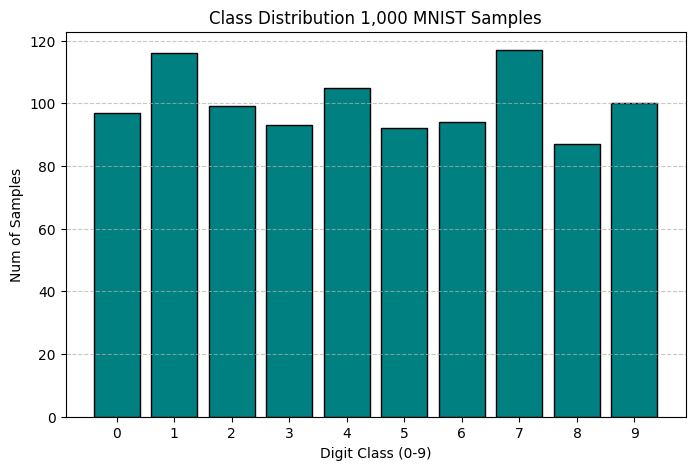

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Subset
# torch.histogram(torch.tensor(mnist_subset), range = None, weight= None, density= False, out= None)

# mnist_subset has label and images
label = []
for item in mnist_subset:
    label.append(item[1])

# integer to float
label_tensor = torch.tensor(label, dtype= torch.float32)

plt.figure(figsize=(8, 5))
plt.hist(label, bins=np.arange(11) - 0.5, rwidth=0.8, color='teal', edgecolor='black')
plt.title('Class Distribution 1,000 MNIST Samples')
plt.xlabel('Digit Class (0-9)')
plt.ylabel('Num of Samples')
plt.xticks(range(10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()